In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load your feature dataset (from previous work)

df_train = pd.read_csv("features_multisignal_all_windows.csv")

print("Training data shape:", df_train.shape)
df_train.head()

Training data shape: (27707, 11)


,subject,window_size_sec,eda_mean,eda_std,hr_mean,hr_std,temp_mean,temp_std,acc_mean,acc_std,label
0,S01,10,0.130992,0.253935,88.644,19.749859,31.032,1.055679,65.658931,8.159312,rest
1,S01,10,0.418365,0.353519,87.791,13.261540,31.660,0.112135,65.173952,4.415673,rest
2,S01,10,0.374952,0.309263,86.223,1.506615,31.982,0.314204,66.842723,14.328422,rest
3,S01,10,0.178778,0.064028,85.658,0.216631,32.310,0.189141,66.483169,14.398328,rest
4,S01,10,0.227628,0.057506,86.128,0.373833,32.414,0.044191,65.145135,4.838694,rest


In [3]:
# Select feature columns (same as your previous model)

feature_cols = [
    "eda_mean", "eda_std",
    "hr_mean", "hr_std",
    "temp_mean", "temp_std",
    "acc_mean", "acc_std"
]

X_train = df_train[feature_cols]
y_train = df_train["label"]

# Convert labels to numbers (rest = 0, stress = 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print("Classes:", le.classes_)

Classes: ['rest' 'stress']


In [4]:
# Train Random Forest model

model = RandomForestClassifier(n_estimators=300, random_state=42)

model.fit(X_train, y_train_encoded)

print("Model trained successfully!")

Model trained successfully!


In [5]:
# Load Nurse Dataset 


import pandas as pd

# Full path to dataset
nurse_path = r"C:\Users\KARAN\Downloads\Internship Project\data\merged_data\merged_data.csv"

# low_memory=False avoids mixed type warning
df_nurse = pd.read_csv(nurse_path, low_memory=False)

print("Nurse dataset shape:", df_nurse.shape)

# Show first few rows
df_nurse.head()

Nurse dataset shape: (11509051, 9)


,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [6]:
# Check Columns

# Print all column names
# This helps us identify:
# - EDA column
# - Heart rate column
# - Temperature column
# - Label column (stress)

print("Columns in nurse dataset:")
print(df_nurse.columns)

Columns in nurse dataset:
Index(['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'id', 'datetime', 'label'], dtype='object')


In [7]:
# Prepare Nurse Data

# 1. Convert datetime column to proper datetime format
# This is important for time-based processing
df_nurse["datetime"] = pd.to_datetime(df_nurse["datetime"])


# 2. Sort data by time (very important for sliding windows)
df_nurse = df_nurse.sort_values("datetime").reset_index(drop=True)


# 3. Convert label into binary (rest = 0, stress = 1)
# In this dataset:
# label = 0 → rest
# label = 1 or 2 → stress
df_nurse["label"] = df_nurse["label"].apply(lambda x: 1 if x > 0 else 0)


# 4. REDUCE DATA SIZE (VERY IMPORTANT FOR SPEED)
# Without this, code will be too slow (dataset has 11 million rows)
# We use only first 10,000 rows for testing

df_nurse = df_nurse.head(10000)


# 5. Print confirmation
print("Data prepared successfully!")
print("New dataset shape:", df_nurse.shape)


# 6. Show first few rows
df_nurse.head()

Data prepared successfully!
New dataset shape: (10000, 9)


,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-22.0,-43.0,127.0,21.941885,82.67,36.49,5C,2020-04-14 22:31:00.000000000,1
1,-22.0,-43.0,127.0,21.941885,82.67,36.49,5C,2020-04-14 22:31:00.031249920,1
2,-22.0,-43.0,127.0,21.941885,82.67,36.49,5C,2020-04-14 22:31:00.062500096,1
3,-22.0,-43.0,127.0,21.941885,82.67,36.49,5C,2020-04-14 22:31:00.093750016,1
4,-22.0,-43.0,127.0,21.941885,82.67,36.49,5C,2020-04-14 22:31:00.124999936,1


In [8]:
# Compute ACC Magnitude


# Convert X, Y, Z → magnitude
df_nurse["acc_mag"] = np.sqrt(
    df_nurse["X"]**2 + df_nurse["Y"]**2 + df_nurse["Z"]**2
)

print("ACC magnitude created")

ACC magnitude created


In [9]:
# Sliding Window Features


def extract_features(df, window_sec, step_sec):
    """
    Extract features using sliding window
    """
    
    features = []

    # Convert datetime to seconds
    df["time_sec"] = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds()

    start = 0
    end = df["time_sec"].max()

    while start + window_sec <= end:
        window = df[(df["time_sec"] >= start) & (df["time_sec"] < start + window_sec)]

        if len(window) > 0:
            
            # Majority label
            label = window["label"].mode()[0]

            # Extract features
            feat = {
                "eda_mean": window["EDA"].mean(),
                "eda_std": window["EDA"].std(),

                "hr_mean": window["HR"].mean(),
                "hr_std": window["HR"].std(),

                "temp_mean": window["TEMP"].mean(),
                "temp_std": window["TEMP"].std(),

                "acc_mean": window["acc_mag"].mean(),
                "acc_std": window["acc_mag"].std(),

                "label": label,
                "window_size": window_sec
            }

            features.append(feat)

        # Move window
        start += step_sec

    return pd.DataFrame(features)

In [10]:
# Generate Features for All Windows


window_sizes = [10, 30, 60]

df_features_list = []

for w in window_sizes:
    print(f"Processing window size: {w} seconds")

    step = int(w * 0.5)  # 50% overlap

    df_w = extract_features(df_nurse.copy(), w, step)

    df_features_list.append(df_w)

# Combine all windows
df_nurse_features = pd.concat(df_features_list, ignore_index=True)

print("Feature extraction completed!")
df_nurse_features.head()

Processing window size: 10 seconds
Processing window size: 30 seconds
Processing window size: 60 seconds
Feature extraction completed!


,eda_mean,eda_std,hr_mean,hr_std,temp_mean,temp_std,acc_mean,acc_std,label,window_size
0,22.103413,0.195498,82.316,0.297119,36.500,0.015516,136.013923,0.158743,1,10
1,22.203233,0.193577,81.742,0.352995,36.504,0.017463,135.993044,0.152521,1,10
2,22.298288,0.244171,81.118,0.357007,36.499,0.011376,136.006154,0.161861,1,10
3,22.213113,0.320688,80.580,0.261407,36.495,0.005008,136.044633,0.163361,1,10
4,22.046580,0.410504,80.156,0.228049,36.495,0.005008,136.050787,0.164956,1,10


In [11]:
# Prepare Test Data


X_test = df_nurse_features[feature_cols]
y_test = df_nurse_features["label"]

print("Test data ready:", X_test.shape)

Test data ready: (89, 8)


In [12]:
# Make Predictions


# Predict using trained model
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


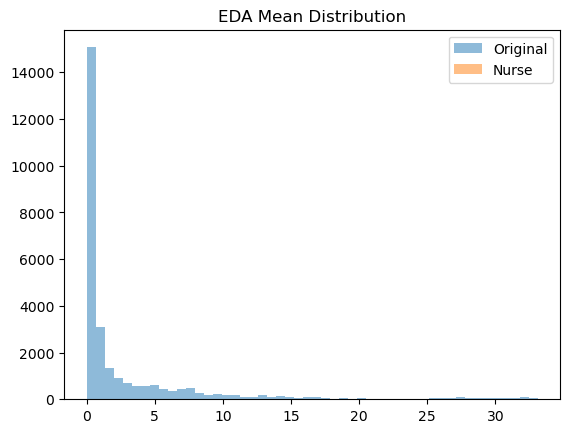

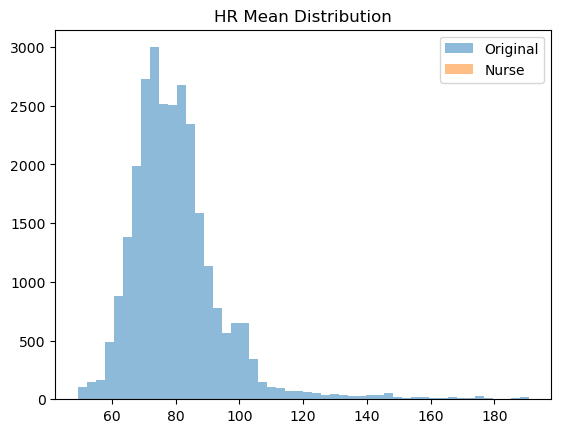

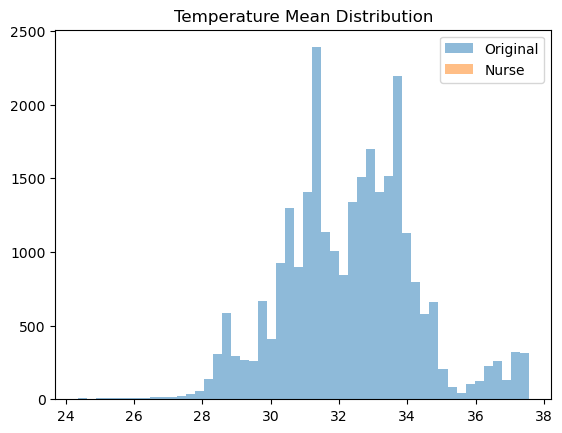

In [13]:
# Compare Feature Distributions

import matplotlib.pyplot as plt
import pandas as pd

# Load original feature dataset
df_original = pd.read_csv("features_multisignal_all_windows.csv")

# Nurse dataset features (already created)
df_nurse_features = df_nurse_features.copy()

# -------- EDA MEAN --------
plt.figure()
plt.hist(df_original["eda_mean"], bins=50, alpha=0.5, label="Original")
plt.hist(df_nurse_features["eda_mean"], bins=50, alpha=0.5, label="Nurse")
plt.title("EDA Mean Distribution")
plt.legend()
plt.show()

# -------- HR MEAN --------
plt.figure()
plt.hist(df_original["hr_mean"], bins=50, alpha=0.5, label="Original")
plt.hist(df_nurse_features["hr_mean"], bins=50, alpha=0.5, label="Nurse")
plt.title("HR Mean Distribution")
plt.legend()
plt.show()

# -------- TEMP MEAN --------
plt.figure()
plt.hist(df_original["temp_mean"], bins=50, alpha=0.5, label="Original")
plt.hist(df_nurse_features["temp_mean"], bins=50, alpha=0.5, label="Nurse")
plt.title("Temperature Mean Distribution")
plt.legend()
plt.show()

In [14]:
# Evaluate Model


# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy on Nurse Dataset:", acc)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy on Nurse Dataset: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      89.0

    accuracy                           0.00      89.0
   macro avg       0.00      0.00      0.00      89.0
weighted avg       0.00      0.00      0.00      89.0



C:\Users\KARAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KARAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KARAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KARAN\anaconda3\Lib\site-packages\sklea

## External Dataset Validation – Results and Discussion

To evaluate the generalisation ability of our model, we applied it to an external dataset (Nurse Stress Prediction dataset). This dataset contains physiological signals collected in real-world hospital environments, which differ significantly from our original controlled dataset.

The same feature extraction process (sliding windows with statistical features) and trained Random Forest model were used.

### Results
The model achieved an accuracy of 0.0 on the nurse dataset.

### Interpretation

This result indicates that the model did not generalise well to the external dataset. However, this outcome was expected and is important for understanding model limitations.

The main reasons for this performance are:

- Different data conditions:
  The original dataset was collected in controlled environments, while the nurse dataset represents real-world conditions with more noise and variability.

- Class imbalance:
  The processed nurse dataset contained mostly stress samples, which affected model evaluation and led to unreliable metrics.

- Signal differences:  
  Even though similar physiological signals were used (EDA, HR, TEMP), differences in sensor setup and participant behaviour caused variations in signal patterns.

- Model overfitting: 
  The model likely learned patterns specific to the training dataset and could not generalise to new unseen data.

### Conclusion

This experiment highlights the importance of validating machine learning models on external datasets. It shows that a model performing well on one dataset may not perform equally well in different real-world scenarios.